In [ ]:
import torch
import app as gr
import torch.nn as nn
from typing import Optional
import torch.nn.functional as F

from model import Transformer, make_src_mask, make_tgt_mask
from matplotlib.ticker import FormatStrFormatter
from tqdm import tqdm

from config import *

from dataset_cfd import *
from lr_scheduler import *
from train import *
from config import *

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr

import json
import os
import io
from PIL import Image

100%|██████████| 64/64 [00:02<00:00, 24.87it/s]


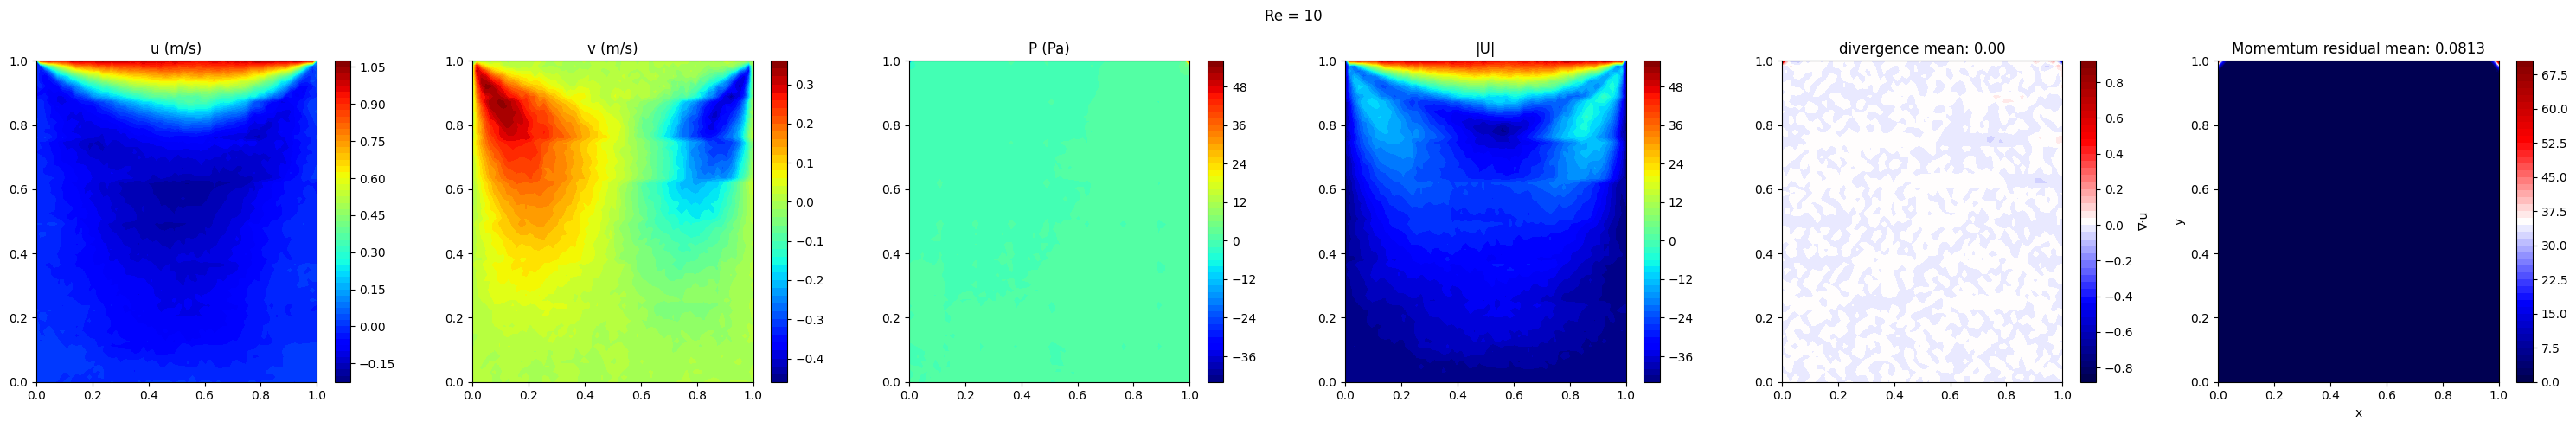

In [2]:
transformer = Transformer(
                        d_model        = D_MODEL,
                        N              = N,
                        num_heads      = NUM_HEADS,
                        d_ff           = D_FF,
                        patch_dim      = PATCH_DIM)


load_checkpoint("checkpoint_with_P.pt", transformer)


def fourier_features(cords: torch.tensor, num_freq = FOURIER_FEATURES):
    # [num_patches, 2] -> [num_patches, num_freq * 2]
    freqs = 2 ** torch.linspace(0, num_freq - 1, num_freq)                   # [num_freqs]
    angles = (cords.unsqueeze(-1) * freqs  * torch.pi)                       # [num_patches, 2, num_freq]
    encoded = torch.cat([torch.sin(angles), torch.cos(angles)], dim = -1)    # [num_patches, 2, num_freq * 2]
    return encoded.view(cords.shape[0], -1)                                  # [num_patches, 2 * num_freq * 2]


patches_per_side = GRID_SIZE // PATCH_SIZE
coords = []
for row in range(patches_per_side):
    for col in range(patches_per_side):
        coords.append([(col+0.5)/patches_per_side, (row+0.5)/patches_per_side])
coords_tensor = torch.tensor(coords, dtype=torch.float32)

def patches_to_contour(patch, num_patches, patch_size, grid_size):

    unrolled = patch.view(num_patches, num_patches, C, patch_size, patch_size)   # (patch_row, patch_col, C, patch_h, patch_w)
    unrolled = unrolled.permute(2, 0, 3, 1, 4).contiguous()                      # (C, patch_row, patch_h, patch_col, patch_w)
    unrolled = unrolled.view(C, grid_size, grid_size)                            # (2, grid_size, grid_size)

    return unrolled

def predict(re_value, model, 
            re_mean, re_std, 
            u_mean, u_std, 
            v_mean, v_std, 
            P_mean, P_std, 
            grid_size, patch_size, patch_dim, fourier_dimension,
            device="cpu", plot: bool = True):
    '''
    magic
    '''

    # normalize using dataset stats
    re_norm = (re_value - re_mean) / re_std
    src = torch.tensor([[re_norm]], dtype=torch.float32).to(device)  # (1, 1)

    patches_per_side = grid_size // patch_size
    coords = []
    for row in range(patches_per_side):
        for col in range(patches_per_side):
            coords.append([(col+0.5)/patches_per_side, (row+0.5)/patches_per_side])
    
    coords_tensor = fourier_features(torch.tensor(coords, dtype=torch.float32), num_freq = FOURIER_FEATURES)

    # decode
    src_mask = make_src_mask(src, -1)
    pred_patches = greedy_decode(
        model         = model, 
        src           = src, 
        src_mask      = src_mask,
        max_len       = (grid_size // patch_size)**2,
        patch_dim     = patch_dim - fourier_dimension, 
        coords_tensor = coords_tensor,
        device        = device, 
        num_freq = 16
    )  # (1, num_patches, patch_dim)


    # unroll patches to (2, 64, 64)
    unrolled = patches_to_contour(pred_patches[0],
                                   grid_size // patch_size,
                                   patch_size,
                                   grid_size)


    u = unrolled[0].detach().cpu()
    v = unrolled[1].detach().cpu()
    P = unrolled[2].detach().cpu()

    # denormalize
    u = (u * u_std) + u_mean
    v = (v * v_std) + v_mean
    P = (P * P_std) + P_mean

    # numerical gradients
    u_np = u
    v_np = v

    du_dx = np.gradient(u_np, axis = 1) # derivative along x (cols)
    du_dy = np.gradient(u_np, axis = 0)
    dv_dy = np.gradient(v_np, axis = 0) # derivative along y (rows)
    dv_dx = np.gradient(v_np, axis = 1)

    d2u_dx2 = np.gradient(du_dx, axis = 1)
    d2u_dy2 = np.gradient(du_dy, axis = 0)
    d2v_dy2 = np.gradient(dv_dy, axis = 0)
    d2v_dx2 = np.gradient(dv_dx, axis = 1)

    dP_dx = np.gradient(P, axis = 1)
    dP_dy = np.gradient(P, axis = 0)



    momentum_res_x = (1 * ((u * du_dx) + (v * du_dy))) + dP_dx + (1/re_value) * (d2u_dx2 + d2u_dy2)
    momentum_res_y = (1 * ((u * dv_dx) + (v * dv_dy))) + dP_dy + (1/re_value) * (d2v_dx2 + d2v_dy2)

    momentum_res =  (momentum_res_x ** 2 + momentum_res_y ** 2)**0.5

    divergence = du_dx + dv_dy

    mag = np.sqrt(u**2 + v**2)

    if plot:
        # u = sharpen_field(u.detach().cpu().numpy(), "bilateral")
        # v = sharpen_field(v.detach().cpu().numpy(), "bilateral")

        # plot
        x_grid = np.linspace(0, 1, grid_size)
        y_grid = np.linspace(0, 1, grid_size)


        fig, axes = plt.subplots(1, 6, figsize=(30, 5))

        # u
        c0 = axes[0].contourf(x_grid, y_grid, u, levels=50, cmap="jet")
        fig.colorbar(c0, ax=axes[0])
        axes[0].set_title("u (m/s)")

        # v
        c1 = axes[1].contourf(x_grid, y_grid, v, levels=50, cmap="jet")
        fig.colorbar(c1, ax=axes[1])
        axes[1].set_title("v (m/s)")

        # p
        c2 = axes[2].contourf(x_grid, y_grid, P, levels=50, cmap="jet")
        fig.colorbar(c2, ax=axes[2])
        axes[2].set_title("P (Pa)")

        # mag
        c3 = axes[3].contourf(x_grid, y_grid, mag, levels=50, cmap="jet")
        fig.colorbar(c2, ax=axes[3])
        # axes[2].streamplot(x_grid, y_grid, u, v, color="white", density=1.2)
        axes[3].set_title("|U|")# + streamlines")


        c4 = axes[4].contourf(x_grid, y_grid, divergence, levels=50, cmap="seismic")
        fig.colorbar(c4, ax=axes[4], label="∇·u")
        axes[4].set_title(f"divergence mean: {divergence.mean():.2f}")

        div_m = axes[5].contourf(x_grid, y_grid, momentum_res, levels=50, cmap="seismic")
        plt.colorbar(div_m, ax=axes[5])
        axes[5].set_title(f"Momemtum residual mean: {momentum_res.mean():.4f}")
        axes[5].set_xlabel("x")
        axes[5].set_ylabel("y")

        plt.suptitle(f"Re = {re_value}")
        plt.tight_layout()
        plt.show()

    return u, v, P, divergence, momentum_res, mag



u, v, P, divergence, momentum_res, mag = predict(re_value = 10, model = transformer, 
                                   re_mean = RE_MEAN, re_std = RE_STD, 
                                   u_mean = U_MEAN,   u_std = U_STD, 
                                   v_mean = V_MEAN,   v_std = V_STD, 
                                   P_mean = P_MEAN,   P_std = P_STD,
                                   grid_size = GRID_SIZE, patch_size = PATCH_SIZE, patch_dim = PATCH_DIM, fourier_dimension = FOURIER_DIMENSIONS,
                                   device = "cpu", plot = True
                                   )

In [16]:
def predict_for_gradio(re_value, model, re_mean, re_std, u_mean, u_std, v_mean, v_std, 
                        P_mean, P_std, grid_size, patch_size, patch_dim, fourier_dimension,
                        device="cpu", plot=True, cmap="jet"): 
    
    # Run your original physics prediction model
    u, v, P, divergence, momentum_res, mag = predict(
        re_value = re_value, model = model, 
        re_mean = re_mean, re_std = re_std, 
        u_mean = u_mean,   u_std = u_std, 
        v_mean = v_mean,   v_std = v_std, 
        P_mean = P_mean,   P_std = P_std,
        grid_size = grid_size, patch_size = patch_size, patch_dim = patch_dim, 
        fourier_dimension = fourier_dimension,
        device = device, plot = False
    )
    
    def render_field_with_colorbar(data, name):
        # Create a clean figure context for every field to prevent memory leaks
        fig, ax = plt.subplots(figsize=(5, 4.2), layout='constrained')
        
        # origin='lower' flips the image vertically to fix the upside-down orientation
        im = ax.imshow(data, cmap=cmap, origin='lower')
        
        # Append a clean, scaled color bar to the right of the fluid field plot
        fig.colorbar(im, ax=ax, shrink=0.85, pad=0.04)
        
        # Clean up the UI canvas by stripping raw matrix pixel axis ticks
        ax.set_title(name, fontsize=12, fontweight='bold')
        ax.axis('off')
        
        # Stream the matplotlib canvas straight into memory buffer as a PNG image
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
        buf.seek(0)
        plt.close(fig) # Completely free memory allocations
        
        return Image.open(buf), name

    # Process all 6 computational fields sequentially into the gallery list array
    gallery_items = [
        render_field_with_colorbar(u, "U-Velocity"),
        render_field_with_colorbar(v, "V-Velocity"),
        render_field_with_colorbar(mag, "Magnitude"),
        render_field_with_colorbar(P, "Pressure (P)"),
        render_field_with_colorbar(divergence, f"Divergence mean: {divergence.mean():.2f}"),
        render_field_with_colorbar(momentum_res, f"Momentum Residual mean: {momentum_res.mean():2f}"),
    ]
    
    return gallery_items

In [17]:
def ui_prediction_wrapper(re_value):
    return predict_for_gradio(
        re_value = re_value, 
        model = transformer, 
        re_mean = RE_MEAN, re_std = RE_STD, 
        u_mean = U_MEAN,   u_std = U_STD, 
        v_mean = V_MEAN,   v_std = V_STD, 
        P_mean = P_MEAN,   P_std = P_STD,
        grid_size = GRID_SIZE, patch_size = PATCH_SIZE, patch_dim = PATCH_DIM, 
        fourier_dimension = FOURIER_DIMENSIONS,
        device = "cpu", plot = True,
    )

with gr.Blocks() as demo:
    gr.Markdown("### Fluid Dynamics Transformer Predictions")
    
    with gr.Row():
        with gr.Column(scale=1):
            re_slider = gr.Slider(minimum=1, maximum=2500, value=10, step=1, label="Reynolds Number (Re)")
            submit_btn = gr.Button("Predict Fields", variant="primary")
            
        with gr.Column(scale=2):
            # Display outputs in a structured 3-column grid layout
            output_gallery = gr.Gallery(
                label="Predicted Physical Fields", 
                columns=3, 
                rows=2, 
                height="auto",
                object_fit="contain"
            )

    # Attach click action to execute the wrapper pipeline
    submit_btn.click(
        fn=ui_prediction_wrapper, 
        inputs=[re_slider], 
        outputs=output_gallery
    )

demo.launch()

* Running on local URL:  http://127.0.0.1:7867
* To create a public link, set `share=True` in `launch()`.


100%|██████████| 64/64 [00:02<00:00, 26.94it/s]
